Abdulaziz Almousa

# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Step 1. Load the data

In [2]:
url = 'https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df[['Hours_Studied']]  
y = df['Marks']             

### Step 2.b print the type of each

In [5]:
print('Type of X:', type(X))
print('Type of y:', type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
# y (Marks) is a continuous numerical variable
# -> This is a REGRESSION task (predicting a continuous output)
print('Target dtype:', y.dtype)
print('Task type: Regression')

Target dtype: float64
Task type: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print('X shape (samples, features):', X.shape)

print('y shape (samples,)          :', y.shape)

X shape (samples, features): (100, 1)
y shape (samples,)          : (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [ ]:
pd.concat([X, y], axis=1).agg(['min', 'max', 'median', 'mean', 'std'])


,Hours_Studied,Marks
min,1.050000,20.190000
max,9.870000,73.260000
median,5.565000,47.485000
mean,5.376300,46.360200
std,2.593013,14.284805


### Step 5. Plot the feature vs the target

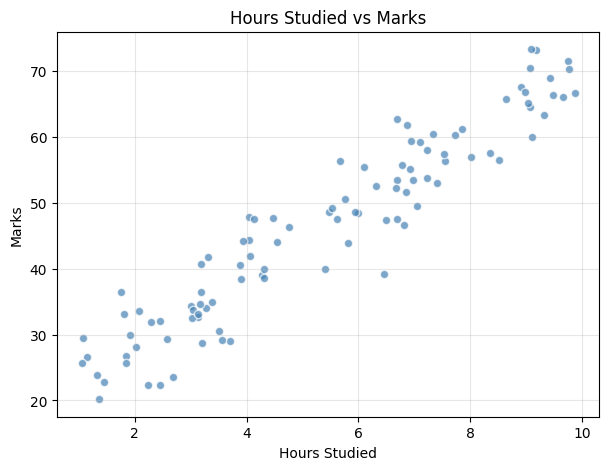

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Hours_Studied'], df['Marks'], color='steelblue', alpha=0.7, edgecolors='white')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours Studied vs Marks')
plt.grid(True, alpha=0.3)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [12]:
corr = df['Hours_Studied'].corr(df['Marks'])
print(f'Pearson r = {corr:.4f}')
print('Relationship: Strong positive (increasing) -- more hours -> higher marks')

Pearson r = 0.9490
Relationship: Strong positive (increasing) -- more hours -> higher marks


### Step 7. Initialize a `LinearRegression` model

In [16]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 80
Test size : 20


### Step 9.a Train the model on the training set

In [18]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [19]:
slope     = model.coef_[0]
intercept = model.intercept_
print(f'Slope (coef_) : {slope:.4f}')
print(f'Intercept     : {intercept:.4f}')
print(f'Equation      : Marks = {slope:.4f} * Hours_Studied + {intercept:.4f}')

Slope (coef_) : 5.1644
Intercept     : 18.5386
Equation      : Marks = 5.1644 * Hours_Studied + 18.5386


### Step 9.c how much marks do we get per 1 hour of study?

In [20]:
print(f'Each additional hour of study adds {slope:.4f} marks')

Each additional hour of study adds 5.1644 marks


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [21]:
gain_10min = slope * (10 / 60)
print(f'10 minutes extra study adds {gain_10min:.4f} marks')

10 minutes extra study adds 0.8607 marks


### Step 9.e if one doesn't study at all, how much marks do they get?

In [22]:
print(f'With 0 hours studied, predicted marks = {intercept:.4f}  (the y-intercept)')

With 0 hours studied, predicted marks = 18.5386  (the y-intercept)


### Step 10. Evaluate the model on the test set

In [23]:
y_pred = model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

MSE  : 14.7311
RMSE : 3.8381
R2   : 0.9258


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [24]:
sample_X    = X_test.sample(3, random_state=1)
sample_y    = y_test.loc[sample_X.index]
sample_pred = model.predict(sample_X)

comparison = pd.DataFrame({
    'Hours_Studied': sample_X['Hours_Studied'].values,
    'True_Marks'   : sample_y.values,
    'Predicted'    : sample_pred.round(2),
    'Error'        : (sample_pred - sample_y.values).round(2)
})
comparison

,Hours_Studied,True_Marks,Predicted,Error
0,2.57,29.25,31.81,2.56
1,1.91,30.00,28.40,-1.60
2,2.30,31.86,30.42,-1.44


### Step 12. Plot the data and the regression line

/Users/abdulazizalmousa/Desktop/SDAIA bootcamp/SDAIA AAI Bootcamp - Abdulaziz Almousa repo/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


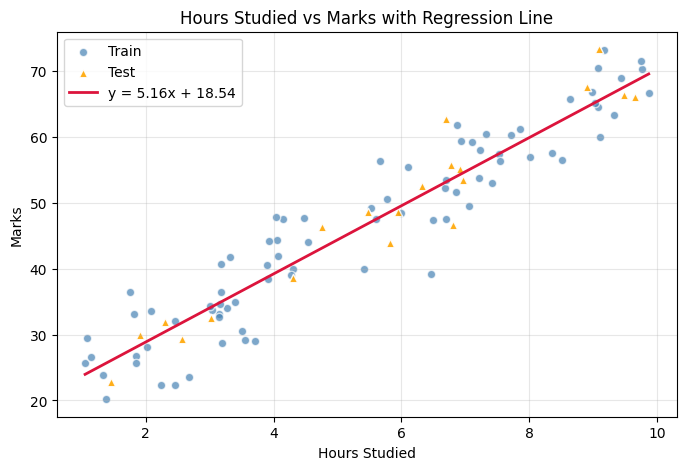

In [25]:
slope_val     = model.coef_[0]
intercept_val = model.intercept_

x_line = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.7, label='Train', edgecolors='white')
plt.scatter(X_test,  y_test,  color='orange',    alpha=0.9, label='Test',  marker='^', edgecolors='white')
plt.plot(x_line, y_line, color='crimson', linewidth=2,
         label=f'y = {slope_val:.2f}x + {intercept_val:.2f}')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours Studied vs Marks with Regression Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()